# Comparación de Modelos Predictivos
En este cuaderno, compararemos múltiples modelos (Random Forest vs XGBoost) para ver cuál predice mejor el riesgo de recontacto.

In [3]:
import pyodbc
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Cargar y preparar datos
conn = pyodbc.connect(f"DRIVER={{ODBC Driver 18 for SQL Server}};SERVER=db;DATABASE=ServicioCiudadanoDW;UID=SA;PWD=J0AhMXX4H0QBrRr8R1U098y8aA1@;TrustServerCertificate=yes;")
df = pd.read_sql("SELECT * FROM vw_v1_limpio", conn)
conn.close()

X = df.drop(columns=['id_interaccion', 'fecha_contacto', 'fecha_carga', 'recontacto_7_dias'])
y = df['recontacto_7_dias']
X = pd.get_dummies(X, columns=X.select_dtypes(include=['object']).columns.tolist(), drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

ratio_desbalance = (y_train == 0).sum() / (y_train == 1).sum()

def evaluar_modelo(modelo, nombre):
    modelo.fit(X_train, y_train)
    y_pred_proba = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    acc = modelo.score(X_test, y_test)
    return auc, acc, y_pred_proba

# Entrenar Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
auc_rf, acc_rf, proba_rf = evaluar_modelo(rf, "Random Forest")

# Entrenar XGBoost
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, scale_pos_weight=ratio_desbalance, random_state=42, eval_metric='auc')
auc_xgb, acc_xgb, proba_xgb = evaluar_modelo(xgb, "XGBoost")
print("✅ Modelos entrenados")


/tmp/ipykernel_188/1095086778.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM vw_v1_limpio", conn)
/tmp/ipykernel_188/1095086778.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X = pd.get_dummies(X, columns=X.select_dtypes(include=['object']).columns.tolist(), drop_first=True)


✅ Modelos entrenados


📊 COMPARACIÓN DE MÉTRICAS


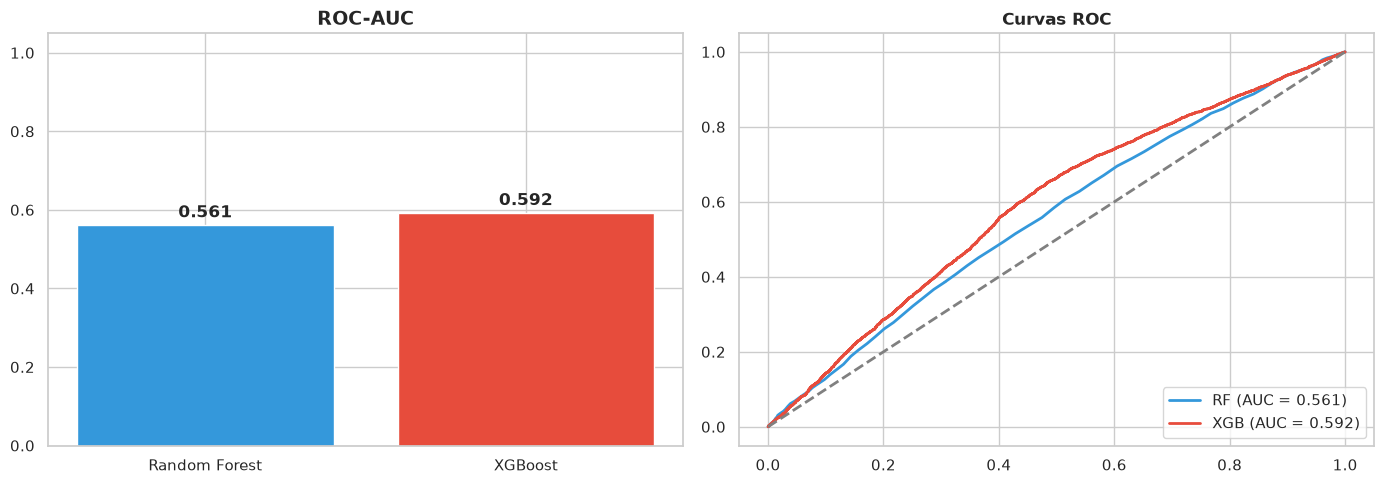

💡 CONCLUSIÓN: XGBoost tiene mejor rendimiento para predecir el recontacto.


In [4]:
# Gráficos comparativos (Estilo del profe)
print("=" * 70)
print("📊 COMPARACIÓN DE MÉTRICAS")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-AUC
axes[0].bar(['Random Forest', 'XGBoost'], [auc_rf, auc_xgb], color=['#3498db', '#e74c3c'])
axes[0].set_title('ROC-AUC', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.05)
for i, v in enumerate([auc_rf, auc_xgb]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

# Curvas ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, proba_xgb)

axes[1].plot(fpr_rf, tpr_rf, color='#3498db', lw=2, label=f'RF (AUC = {auc_rf:.3f})')
axes[1].plot(fpr_xgb, tpr_xgb, color='#e74c3c', lw=2, label=f'XGB (AUC = {auc_xgb:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
axes[1].set_title('Curvas ROC', fontweight='bold')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"💡 CONCLUSIÓN: {'XGBoost' if auc_xgb > auc_rf else 'Random Forest'} tiene mejor rendimiento para predecir el recontacto.")
